# llm_gemini_format.json 디코딩 테스트

이 노트북은 `llm_gemini_format.json` 파일을 디코딩하여 이미지를 복원하고 시각화합니다.

## Format 2 구조
- Part 1: 텍스트 (순수 데이터 설명)
- Part 2-4: 이미지 데이터 (Base64 인코딩된 PNG)


In [1]:
import json
import base64
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# 프로젝트 루트 경로 추가
sys.path.append('..')


## 1. JSON 파일 로드


In [2]:
# JSON 파일 경로 설정
json_path = Path("../outputs/Primary_Arc_Bead_1/llm_gemini_format.json")

# JSON 파일 로드
print(f"JSON 파일 로드 중: {json_path}")
with open(json_path, 'r', encoding='utf-8') as f:
    gemini_format = json.load(f)

print(f"\n✓ JSON 파일 로드 완료")
print(f"  총 Parts 수: {len(gemini_format)}")
print(f"  예상: 4 parts (텍스트 1개 + 이미지 3개)")


JSON 파일 로드 중: ..\outputs\Primary_Arc_Bead_1\llm_gemini_format.json

✓ JSON 파일 로드 완료
  총 Parts 수: 4
  예상: 4 parts (텍스트 1개 + 이미지 3개)


## 2. Part 1 (텍스트 데이터) 확인


In [3]:
# Part 1: 텍스트 데이터
text_part = gemini_format[0]

print("Part 1 (텍스트) 내용:")
print("=" * 60)
print(text_part)
print("=" * 60)
print(f"\n텍스트 길이: {len(text_part)} 문자")
print(f"지시문 제거 확인: {'분석해주세요' not in text_part and '당신은' not in text_part}")


Part 1 (텍스트) 내용:
단락흔 이미지 처리 파이프라인 분석 데이터

[처리 단계]
1. Enhancer: Real-ESRGAN 4x 초해상도 확대
2. Filter: CLAHE 텍스처 강조 필터
3. Metrics: 형태학적 분석

[형태학적 메트릭스]
{"circularity": 0.138, "solidity": 0.692, "area": 332730, "area_ratio": 69.18499234812695}

[비교 분석 데이터]
{"brightness_change": 2.269917742364754, "pixel_difference_mean": 8.75538611462284, "pixel_difference_max": 108.0}

[이미지 매핑]
- 첫 번째 이미지: Enhancer 결과 (Real-ESRGAN 4x 확대)
- 두 번째 이미지: Filter 결과 (CLAHE 텍스처 강조)
- 세 번째 이미지: Analysis Mask (형태학적 분석 이진 마스크)

텍스트 길이: 481 문자
지시문 제거 확인: True


## 3. 이미지 데이터 디코딩


In [4]:
# 이미지 디코딩 함수
def decode_image_from_gemini_format(part, part_name):
    """
    Gemini Format Part에서 이미지를 디코딩합니다.
    
    Args:
        part: Gemini Format Part (dict)
        part_name: Part 이름 (디버깅용)
    
    Returns:
        디코딩된 이미지 (numpy.ndarray)
    """
    if 'inline_data' not in part:
        raise ValueError(f"{part_name}: 'inline_data' 키가 없습니다")
    
    inline_data = part['inline_data']
    mime_type = inline_data.get('mime_type', '')
    base64_data = inline_data.get('data', '')
    
    print(f"\n{part_name}:")
    print(f"  mime_type: {mime_type}")
    print(f"  Base64 데이터 길이: {len(base64_data)} 문자")
    
    # Base64 디코딩
    try:
        image_bytes = base64.b64decode(base64_data)
        print(f"  디코딩된 바이트 크기: {len(image_bytes)} bytes ({len(image_bytes)/1024:.1f} KB)")
        
        # PNG 시그니처 확인
        if image_bytes[:4] == b'\x89PNG':
            print(f"  ✓ PNG 형식 확인됨")
        else:
            print(f"  ⚠ PNG 시그니처 없음")
        
        # OpenCV로 이미지 디코딩
        nparr = np.frombuffer(image_bytes, np.uint8)
        
        if mime_type == 'image/png':
            # PNG는 컬러/그레이스케일 자동 감지
            img = cv2.imdecode(nparr, cv2.IMREAD_UNCHANGED)
        else:
            # 기타 형식은 컬러로 디코딩
            img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
        
        if img is None:
            raise ValueError("이미지 디코딩 실패")
        
        print(f"  이미지 크기: {img.shape}")
        print(f"  ✓ 이미지 디코딩 성공")
        
        return img
    
    except Exception as e:
        print(f"  ✗ 디코딩 실패: {e}")
        raise

# 각 이미지 디코딩
enhanced_img = decode_image_from_gemini_format(gemini_format[1], "Part 2 (Enhanced 이미지)")
filtered_img = decode_image_from_gemini_format(gemini_format[2], "Part 3 (Filtered 이미지)")
mask_img = decode_image_from_gemini_format(gemini_format[3], "Part 4 (Analysis Mask)")



Part 2 (Enhanced 이미지):
  mime_type: image/png
  Base64 데이터 길이: 1927604 문자
  디코딩된 바이트 크기: 1445701 bytes (1411.8 KB)
  ✓ PNG 형식 확인됨
  이미지 크기: (532, 904, 3)
  ✓ 이미지 디코딩 성공

Part 3 (Filtered 이미지):
  mime_type: image/png
  Base64 데이터 길이: 1927604 문자
  디코딩된 바이트 크기: 1445701 bytes (1411.8 KB)
  ✓ PNG 형식 확인됨
  이미지 크기: (532, 904, 3)
  ✓ 이미지 디코딩 성공

Part 4 (Analysis Mask):
  mime_type: image/png
  Base64 데이터 길이: 643060 문자
  디코딩된 바이트 크기: 482294 bytes (471.0 KB)
  ✓ PNG 형식 확인됨
  이미지 크기: (532, 904)
  ✓ 이미지 디코딩 성공


## 4. 이미지 시각화


C:\Users\loidn\AppData\Local\Temp\ipykernel_8832\1604443269.py:27: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\loidn\AppData\Local\Temp\ipykernel_8832\1604443269.py:27: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\loidn\AppData\Local\Temp\ipykernel_8832\1604443269.py:27: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\loidn\AppData\Local\Temp\ipykernel_8832\1604443269.py:27: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\loidn\AppData\Local\Temp\ipykernel_8832\1604443269.py:27: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\loidn\Documents\Projects\P_04_Scope\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLL

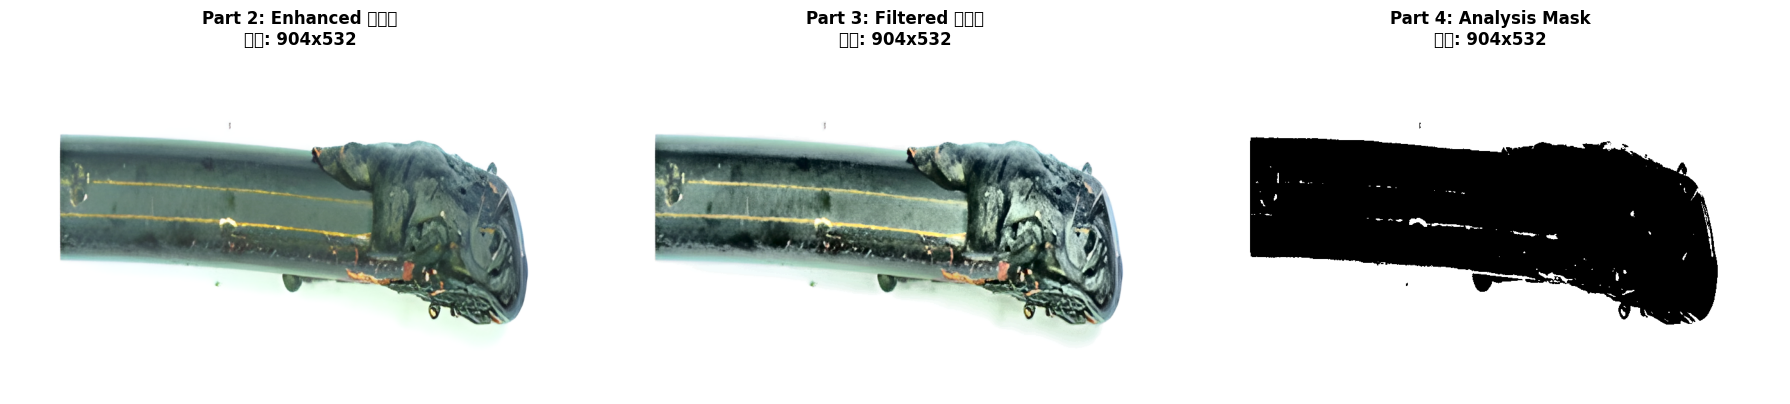


✓ 모든 이미지 디코딩 및 시각화 완료


In [5]:
# 이미지 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Enhanced 이미지
axes[0].imshow(cv2.cvtColor(enhanced_img, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Part 2: Enhanced 이미지\n크기: {enhanced_img.shape[1]}x{enhanced_img.shape[0]}', 
                  fontsize=12, fontweight='bold')
axes[0].axis('off')

# Filtered 이미지
axes[1].imshow(cv2.cvtColor(filtered_img, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Part 3: Filtered 이미지\n크기: {filtered_img.shape[1]}x{filtered_img.shape[0]}', 
                  fontsize=12, fontweight='bold')
axes[1].axis('off')

# Analysis Mask
if len(mask_img.shape) == 2:
    # 그레이스케일 이미지
    axes[2].imshow(mask_img, cmap='gray')
else:
    # 컬러 이미지
    axes[2].imshow(cv2.cvtColor(mask_img, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'Part 4: Analysis Mask\n크기: {mask_img.shape[1]}x{mask_img.shape[0]}', 
                  fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("\n✓ 모든 이미지 디코딩 및 시각화 완료")


## 5. 이미지 저장 (검증용)


In [6]:
# 디코딩된 이미지 저장 (검증용)
output_dir = Path("outputs/decoded_gemini_format")
output_dir.mkdir(exist_ok=True)

# Enhanced 이미지 저장
enhanced_path = output_dir / "decoded_enhanced.png"
cv2.imwrite(str(enhanced_path), enhanced_img)
print(f"✓ Enhanced 이미지 저장: {enhanced_path}")

# Filtered 이미지 저장
filtered_path = output_dir / "decoded_filtered.png"
cv2.imwrite(str(filtered_path), filtered_img)
print(f"✓ Filtered 이미지 저장: {filtered_path}")

# Analysis Mask 저장
mask_path = output_dir / "decoded_mask.png"
cv2.imwrite(str(mask_path), mask_img)
print(f"✓ Analysis Mask 저장: {mask_path}")

print(f"\n모든 이미지가 {output_dir} 디렉토리에 저장되었습니다.")


✓ Enhanced 이미지 저장: outputs\decoded_gemini_format\decoded_enhanced.png
✓ Filtered 이미지 저장: outputs\decoded_gemini_format\decoded_filtered.png
✓ Analysis Mask 저장: outputs\decoded_gemini_format\decoded_mask.png

모든 이미지가 outputs\decoded_gemini_format 디렉토리에 저장되었습니다.


## 6. 검증 요약


In [7]:
print("=" * 60)
print("검증 요약")
print("=" * 60)
print(f"\n✓ JSON 파일 구조: 정상 ({len(gemini_format)} parts)")
print(f"✓ Part 1 (텍스트): {len(gemini_format[0])} 문자, 지시문 제거 확인")
print(f"✓ Part 2 (Enhanced): {enhanced_img.shape[1]}x{enhanced_img.shape[0]} 크기")
print(f"✓ Part 3 (Filtered): {filtered_img.shape[1]}x{filtered_img.shape[0]} 크기")
print(f"✓ Part 4 (Mask): {mask_img.shape[1]}x{mask_img.shape[0]} 크기")
print(f"\n✓ 모든 이미지 디코딩 성공")
print(f"✓ Format 2 방식 정상 작동 확인")
print("=" * 60)


검증 요약

✓ JSON 파일 구조: 정상 (4 parts)
✓ Part 1 (텍스트): 481 문자, 지시문 제거 확인
✓ Part 2 (Enhanced): 904x532 크기
✓ Part 3 (Filtered): 904x532 크기
✓ Part 4 (Mask): 904x532 크기

✓ 모든 이미지 디코딩 성공
✓ Format 2 방식 정상 작동 확인
